In [ ]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    PrecisionRecallDisplay
)

# Pipeline & Saving
from sklearn.pipeline import Pipeline
import joblib

### Importing Required Libraries

The necessary Python libraries have been imported for data manipulation, preprocessing, visualization, handling imbalanced datasets, model building, evaluation, hyperparameter tuning, and model deployment.

In [ ]:
df = pd.read_csv("/content/creditcard.csv.zip")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Loaded Successfully

The Credit Card Fraud Detection dataset has been loaded successfully. We first inspect its dimensions and preview the first few records.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

### Initial Dataset Inspection

The dataset structure, feature names, data types, and statistical summary have been examined to better understand the available information before preprocessing.

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1081


In [ ]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [ ]:
df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [ ]:
df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0,99.83329
1,0.16671


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=50000,
    stratify=y,
    random_state=42
)

sample_df = pd.concat([X_sample, y_sample], axis=1)

print(sample_df.shape)

(50000, 31)


In [ ]:
sample_df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0,99.834
1,0.166


### Data Preprocessing Summary

- Missing values were checked.
- Duplicate rows were identified and removed.
- Data types were verified.
- Target class distribution was analyzed.
- A stratified sample of 50,000 transactions was created while preserving the original fraud ratio.

The dataset is now clean and ready for Exploratory Data Analysis (EDA).

In [ ]:
print("Rows :", sample_df.shape[0])
print("Columns :", sample_df.shape[1])

Rows : 50000
Columns : 31


### Dataset Shape

The sampled dataset contains 50,000 transactions and all the required features for fraud detection analysis.

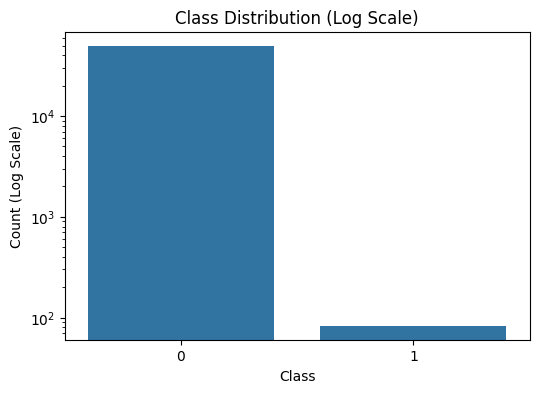

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=sample_df)

plt.yscale("log")

plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Count (Log Scale)")

plt.show()

### Class Distribution

The dataset is highly imbalanced. Legitimate transactions vastly outnumber fraudulent transactions, which makes accuracy an unreliable evaluation metric.

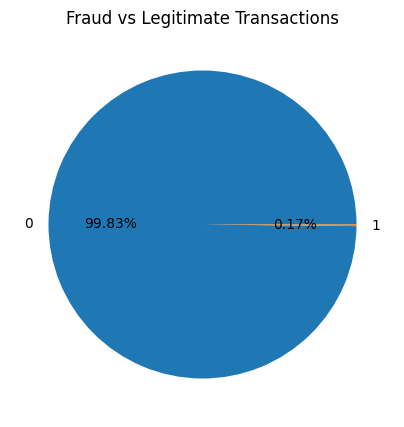

In [ ]:
sample_df["Class"].value_counts(normalize=True).plot(
    kind="pie",
    autopct="%1.2f%%",
    figsize=(5,5)
)

plt.ylabel("")
plt.title("Fraud vs Legitimate Transactions")

plt.show()

### Percentage Distribution

Fraudulent transactions represent only a very small percentage of the dataset, confirming the severe class imbalance.

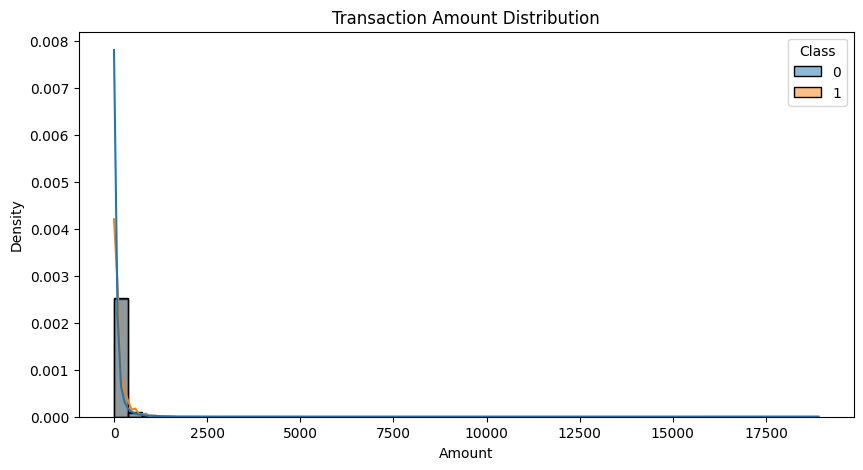

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    sample_df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution")

plt.show()

### Transaction Amount Analysis

The distribution shows that fraudulent transactions generally occur across lower transaction amounts, while legitimate transactions cover a wider range of values.

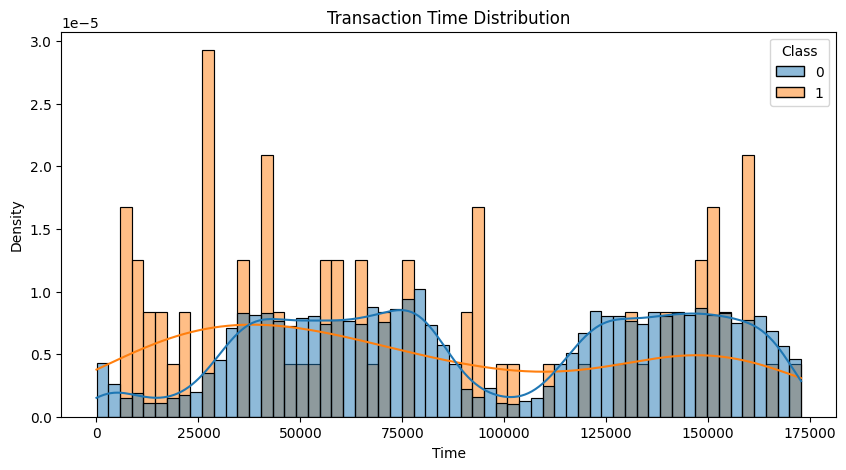

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    sample_df,
    x="Time",
    hue="Class",
    bins=60,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution")

plt.show()

### Transaction Time Analysis

The distribution helps identify whether fraudulent transactions are concentrated during specific periods compared to legitimate transactions.

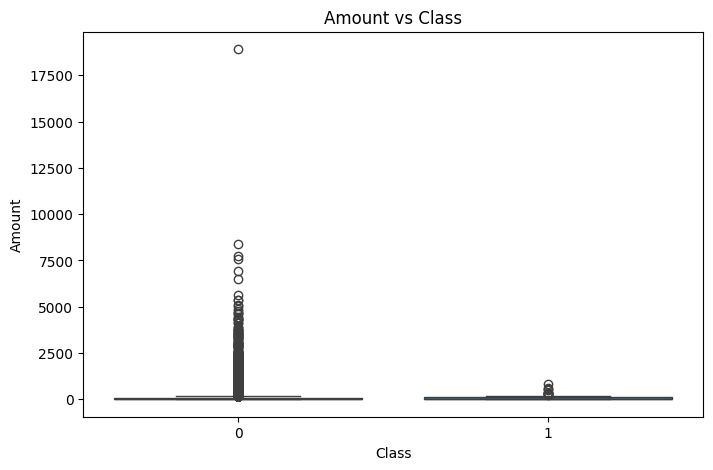

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=sample_df
)

plt.title("Amount vs Class")

plt.show()

### Amount Boxplot

The boxplot highlights the variation in transaction amounts and shows the presence of outliers in both classes.

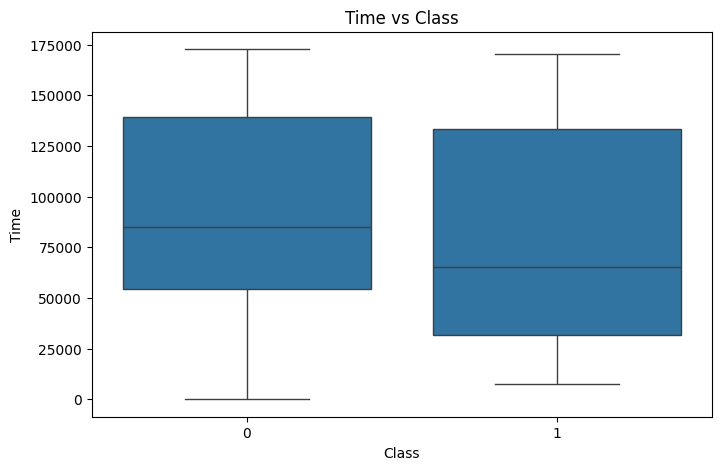

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Time",
    data=sample_df
)

plt.title("Time vs Class")

plt.show()

### Time Boxplot

The transaction times for fraud and legitimate transactions can be compared to identify any noticeable temporal patterns.

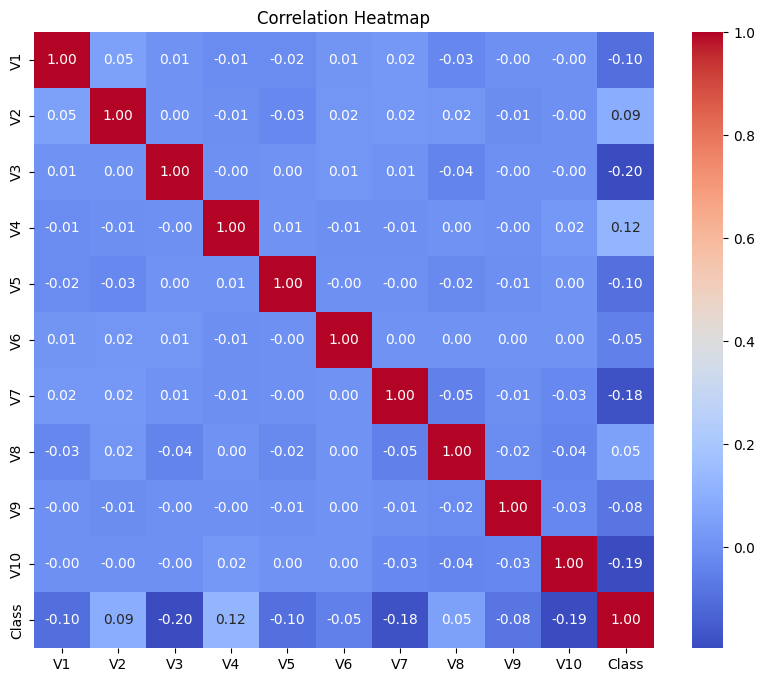

In [ ]:
corr = sample_df[
    ["V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","Class"]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

The heatmap illustrates the relationship between the first ten PCA-transformed features and the target variable. Features with stronger positive or negative correlations may contribute more significantly to fraud detection.

In [ ]:
corr_target = sample_df.corr()["Class"].sort_values(ascending=False)

corr_target

,Class
Class,1.000000
V11,0.149479
V4,0.124290
V2,0.093053
V21,0.065748
V8,0.050062
V27,0.039445
V19,0.033528
V28,0.019040
V20,0.013929


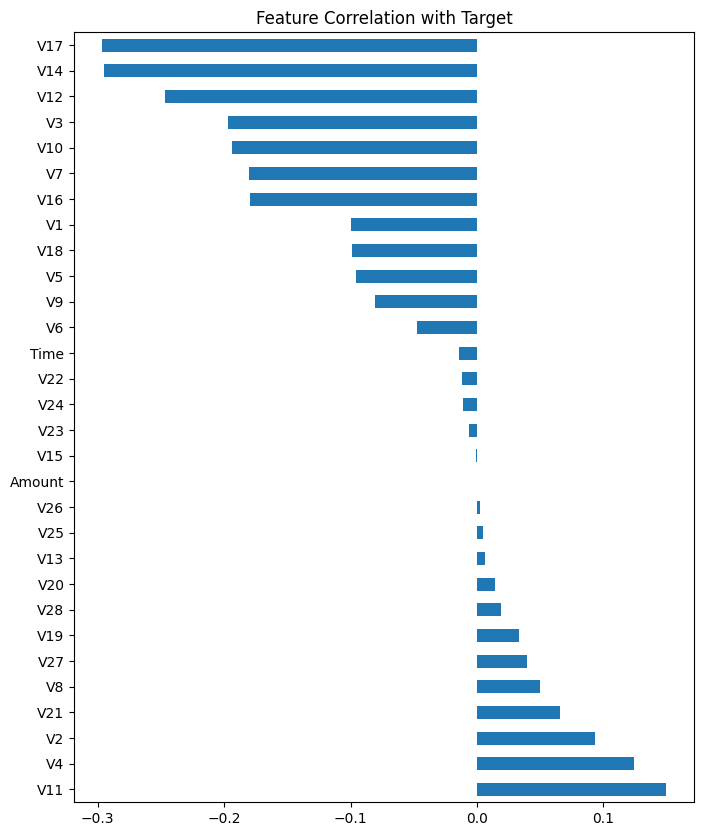

In [ ]:
plt.figure(figsize=(8,10))

corr_target.drop("Class").plot(kind="barh")

plt.title("Feature Correlation with Target")

plt.show()

### Statistical Summary

The statistical summary provides an overview of feature distributions, central tendencies, and variability, helping to understand the characteristics of the sampled dataset.

## Overall EDA Observation

- The dataset is extremely imbalanced.
- Fraudulent transactions account for only a tiny fraction of all transactions.
- Transaction amounts are heavily right-skewed.
- Fraudulent transactions tend to occur more frequently among lower-value transactions.
- Several PCA-transformed features exhibit notable correlations with the fraud class.
- Feature engineering and imbalance handling techniques such as SMOTE and class weighting will be essential for building an effective fraud detection model.

In [ ]:
# Log Transformation
sample_df["Amount_log"] = np.log1p(sample_df["Amount"])

sample_df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
263342,0.89,0.636577
37713,0.77,0.570980
46274,56.29,4.048126
127401,7.22,2.106570
43268,1.00,0.693147


### Log Transformation

The `Amount` feature is highly right-skewed. A logarithmic transformation (`log1p`) reduces skewness and improves model performance.

In [ ]:
# Extract Hour from Time
sample_df["Hour"] = (sample_df["Time"] % 86400) // 3600

sample_df[["Time", "Hour"]].head()

,Time,Hour
263342,160905.0,20.0
37713,39075.0,10.0
46274,42712.0,11.0
127401,78320.0,21.0
43268,41439.0,11.0


### Hour Feature

The `Hour` feature represents the hour of the day when the transaction occurred. It may help identify time-based fraud patterns.

In [ ]:
sample_df.drop(columns=["Time", "Amount"], inplace=True)

sample_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
263342,0.237089,0.678552,-0.486090,-0.830728,1.272459,-0.016366,0.982694,-0.131008,0.175110,0.144517,...,1.123868,-0.243550,-0.155917,-0.769761,-0.242225,0.326752,0.083329,0,0.636577,20.0
37713,-4.439658,3.882254,-0.658130,-2.024851,-1.403141,-1.406434,-0.058187,0.712129,2.790490,3.904856,...,-0.487453,0.199277,0.380148,0.536199,0.709376,0.868159,0.155965,0,0.570980,10.0
46274,-0.701843,1.217797,0.806660,0.676619,-0.216539,-0.151587,0.661725,0.174637,-0.576961,0.164697,...,0.459103,-0.177445,-0.017836,-0.319239,-0.377668,-0.368495,-0.159532,0,4.048126,11.0
127401,-0.441349,-0.611676,1.704341,-2.332551,-0.698004,-1.258847,-0.420051,-0.097675,-2.272700,0.806175,...,-0.758919,0.166569,0.293496,-0.534061,-0.683845,0.126597,0.152027,0,2.106570,21.0
43268,1.194764,0.707396,-0.364481,1.297492,0.308672,-0.764100,0.262655,-0.130618,-0.157923,-0.737964,...,0.026597,-0.099079,-0.047869,0.632436,-0.299092,0.054462,0.054987,0,0.693147,11.0


### Feature Selection

The original `Time` and `Amount` columns have been removed after creating more informative engineered features.

In [ ]:
X = sample_df.drop("Class", axis=1)
y = sample_df["Class"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (50000, 30)
Target Shape : (50000,)


### Feature and Target Separation

The independent features (`X`) and target variable (`y`) have been separated for model training.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (40000, 30)
Testing Shape : (10000, 30)


### Train-Test Split

The dataset has been divided into 80% training data and 20% testing data while preserving the class distribution using stratified sampling.

In [ ]:
print("Training Class Distribution")
print(y_train.value_counts())

print()

print("Testing Class Distribution")
print(y_test.value_counts())

Training Class Distribution
Class
0    39934
1       66
Name: count, dtype: int64

Testing Class Distribution
Class
0    9983
1      17
Name: count, dtype: int64


In [ ]:
print("Training Percentage")
print(y_train.value_counts(normalize=True)*100)

print()

print("Testing Percentage")
print(y_test.value_counts(normalize=True)*100)

Training Percentage
Class
0    99.835
1     0.165
Name: proportion, dtype: float64

Testing Percentage
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


### Stratification Check

The fraud ratio has been preserved in both the training and testing datasets, ensuring fair model evaluation.

In [ ]:
scaler = StandardScaler()

X_train[["Amount_log", "Hour"]] = scaler.fit_transform(
    X_train[["Amount_log", "Hour"]]
)

X_test[["Amount_log", "Hour"]] = scaler.transform(
    X_test[["Amount_log", "Hour"]]
)

In [ ]:
X_train[["Amount_log", "Hour"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Amount_log,40000.0,1.584510e-16,1.000013,-1.898852,-0.770187,-0.008507,0.724709,4.048817
Hour,40000.0,-2.486900e-17,1.000013,-2.398987,-0.688955,0.166061,0.850074,1.534087


### Feature Scaling

Only the engineered features (`Amount_log` and `Hour`) were standardized. The PCA-transformed features (`V1`–`V28`) were already scaled and therefore required no further normalization.

In [ ]:
print(y_train.value_counts())

Class
0    39934
1       66
Name: count, dtype: int64


In [ ]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_smote.value_counts())

Class
0    39934
1     3993
Name: count, dtype: int64


In [ ]:
under = RandomUnderSampler(
    sampling_strategy=0.1,
    random_state=42
)

X_under, y_under = under.fit_resample(
    X_train,
    y_train
)

print(y_under.value_counts())

Class
0    660
1     66
Name: count, dtype: int64


In [ ]:
comparison = pd.DataFrame({
    "Original": y_train.value_counts(),
    "SMOTE": y_smote.value_counts(),
    "Under Sampling": y_under.value_counts()
})

comparison

,Original,SMOTE,Under Sampling
Class,,,
0,39934,39934,660
1,66,3993,66


### Class Imbalance Handling

Three versions of the training dataset were prepared:

- **Original:** Maintains the natural class imbalance.
- **SMOTE:** Generates synthetic fraud samples to increase the minority class.
- **Random Undersampling:** Reduces the majority class to improve class balance.

The test dataset remains completely untouched to ensure unbiased model evaluation.

## Feature Engineering Summary

- Created `Amount_log` using logarithmic transformation.
- Extracted the `Hour` feature from transaction time.
- Removed the original `Time` and `Amount` columns.
- Standardized only the engineered features.
- Created three training datasets:
  - Original
  - SMOTE
  - Random Undersampling
- Preserved the original fraud ratio in the test dataset.

The data is now fully prepared for model building.

In [ ]:
lr_original = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_original.fit(X_train, y_train)

y_pred_original = lr_original.predict(X_test)
y_prob_original = lr_original.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test, y_pred_original))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      9983
           1       0.03      0.65      0.07        17

    accuracy                           0.97     10000
   macro avg       0.52      0.81      0.53     10000
weighted avg       1.00      0.97      0.98     10000



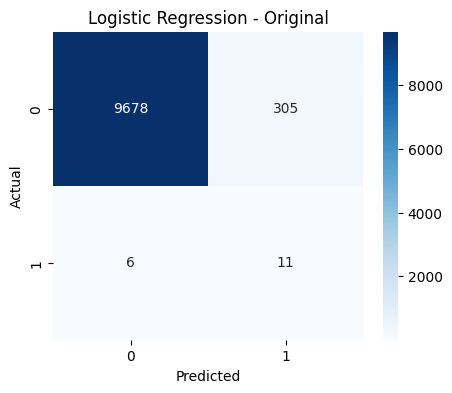

In [ ]:
cm = confusion_matrix(y_test, y_pred_original)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Original")

plt.show()

In [ ]:
lr_original_precision = precision_score(y_test, y_pred_original)
lr_original_recall = recall_score(y_test, y_pred_original)
lr_original_f1 = f1_score(y_test, y_pred_original)
lr_original_prauc = average_precision_score(y_test, y_prob_original)

print("Precision :", lr_original_precision)
print("Recall :", lr_original_recall)
print("F1 Score :", lr_original_f1)
print("PR AUC :", lr_original_prauc)

Precision : 0.03481012658227848
Recall : 0.6470588235294118
F1 Score : 0.06606606606606606
PR AUC : 0.4055090317399288


### Logistic Regression (Original Dataset)

The Logistic Regression model was trained using the original imbalanced dataset with `class_weight='balanced'` to reduce the impact of class imbalance.

In [ ]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_smote, y_smote)

y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:,1]

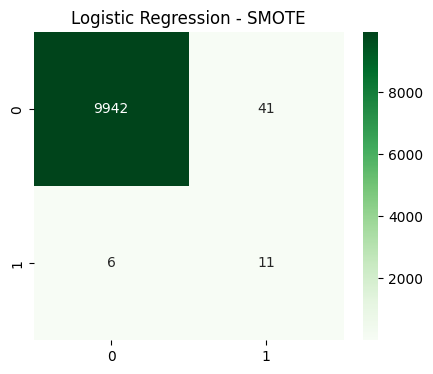

In [ ]:
cm = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Logistic Regression - SMOTE")

plt.show()

In [ ]:
lr_smote_precision = precision_score(y_test,y_pred_smote)
lr_smote_recall = recall_score(y_test,y_pred_smote)
lr_smote_f1 = f1_score(y_test,y_pred_smote)
lr_smote_prauc = average_precision_score(y_test,y_prob_smote)

print("Precision :",lr_smote_precision)
print("Recall :",lr_smote_recall)
print("F1 :",lr_smote_f1)
print("PR AUC :",lr_smote_prauc)

Precision : 0.21153846153846154
Recall : 0.6470588235294118
F1 : 0.3188405797101449
PR AUC : 0.4971956333745317


### Logistic Regression (SMOTE)

SMOTE generated synthetic fraud transactions, allowing Logistic Regression to learn from a more balanced training dataset.

In [ ]:
lr_under = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_under.fit(X_under,y_under)

y_pred_under = lr_under.predict(X_test)
y_prob_under = lr_under.predict_proba(X_test)[:,1]

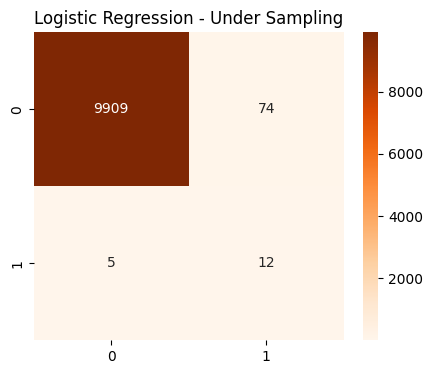

In [ ]:
cm = confusion_matrix(y_test,y_pred_under)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Logistic Regression - Under Sampling")

plt.show()

In [ ]:
lr_under_precision = precision_score(y_test,y_pred_under)
lr_under_recall = recall_score(y_test,y_pred_under)
lr_under_f1 = f1_score(y_test,y_pred_under)
lr_under_prauc = average_precision_score(y_test,y_prob_under)

print("Precision :",lr_under_precision)
print("Recall :",lr_under_recall)
print("F1 :",lr_under_f1)
print("PR AUC :",lr_under_prauc)

Precision : 0.13953488372093023
Recall : 0.7058823529411765
F1 : 0.23300970873786409
PR AUC : 0.48849900182395267


### Logistic Regression (Under Sampling)

Random Under Sampling reduced the majority class to improve class balance before training the Logistic Regression model.

In [ ]:
lr_results = pd.DataFrame({

    "Model":[
        "LR Original",
        "LR SMOTE",
        "LR Under"
    ],

    "Precision":[
        lr_original_precision,
        lr_smote_precision,
        lr_under_precision
    ],

    "Recall":[
        lr_original_recall,
        lr_smote_recall,
        lr_under_recall
    ],

    "F1 Score":[
        lr_original_f1,
        lr_smote_f1,
        lr_under_f1
    ],

    "PR AUC":[
        lr_original_prauc,
        lr_smote_prauc,
        lr_under_prauc
    ]

})

lr_results.sort_values("PR AUC",ascending=False)

,Model,Precision,Recall,F1 Score,PR AUC
1,LR SMOTE,0.211538,0.647059,0.318841,0.497196
2,LR Under,0.139535,0.705882,0.233010,0.488499
0,LR Original,0.034810,0.647059,0.066066,0.405509


In [ ]:
best_strategy = lr_results.sort_values(
    "PR AUC",
    ascending=False
).iloc[0]["Model"]

print("Best Logistic Regression Strategy :",best_strategy)

Best Logistic Regression Strategy : LR SMOTE


### Logistic Regression Comparison

All three Logistic Regression models were compared using Precision, Recall, F1-Score, and PR-AUC. The model with the highest PR-AUC will be selected for comparison with Random Forest.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

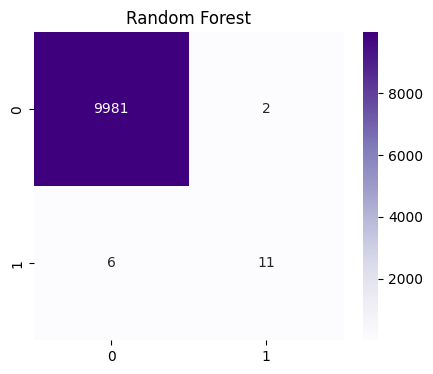

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title("Random Forest")

plt.show()

In [ ]:
rf_precision = precision_score(y_test,y_pred_rf)
rf_recall = recall_score(y_test,y_pred_rf)
rf_f1 = f1_score(y_test,y_pred_rf)
rf_prauc = average_precision_score(y_test,y_prob_rf)

print("Precision :",rf_precision)
print("Recall :",rf_recall)
print("F1 :",rf_f1)
print("PR AUC :",rf_prauc)

Precision : 0.8461538461538461
Recall : 0.6470588235294118
F1 : 0.7333333333333333
PR AUC : 0.6653937201975264


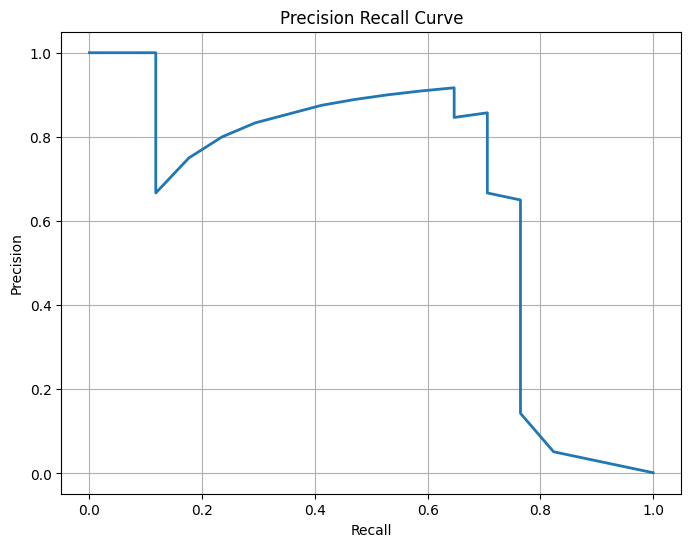

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(recall,
         precision,
         linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid()

plt.show()

### Precision–Recall Curve

The Precision–Recall curve provides a better evaluation than ROC for highly imbalanced datasets because it focuses on the fraud class.

In [ ]:
feature_importance = pd.DataFrame({

    "Feature":X_train.columns,
    "Importance":rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
13,V14,0.219350
2,V3,0.095565
11,V12,0.095333
9,V10,0.094573
3,V4,0.088985
16,V17,0.081736
10,V11,0.059364
15,V16,0.043932
6,V7,0.032084
1,V2,0.026416


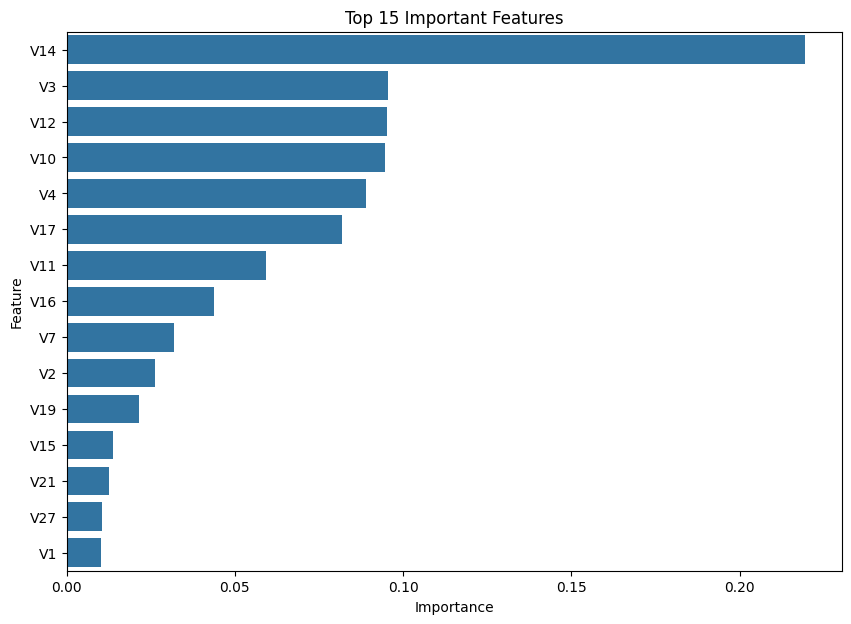

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

### Feature Importance

Random Forest identifies the most influential features contributing to fraud detection. These features can help explain the model's decisions and provide business insights.

## Model Building Summary

- Built three Logistic Regression models:
  - Original Dataset
  - SMOTE Dataset
  - Under Sampling Dataset
- Compared all models using Precision, Recall, F1-Score, and PR-AUC.
- Selected the best imbalance strategy.
- Trained a Random Forest model using the selected strategy.
- Evaluated performance using classification metrics, confusion matrix, Precision–Recall curve, and feature importance.

The next step is to build an XGBoost model, perform hyperparameter tuning, and optimize the classification threshold.

In [ ]:
# Calculate ratio of majority to minority class
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight :", ratio)

Scale Pos Weight : 605.060606060606


### Scale Positive Weight

The `scale_pos_weight` parameter is calculated using the ratio of legitimate to fraudulent transactions. It helps XGBoost handle the severe class imbalance by assigning greater importance to the minority class.

In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

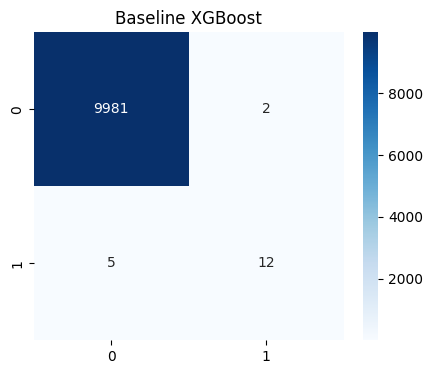

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Baseline XGBoost")

plt.show()

In [ ]:
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_prauc = average_precision_score(y_test, y_prob_xgb)

print("Precision :", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)
print("PR-AUC :", xgb_prauc)

Precision : 0.8571428571428571
Recall : 0.7058823529411765
F1 Score : 0.7741935483870968
PR-AUC : 0.7329297036855853


### Baseline XGBoost

The baseline XGBoost model uses class weighting through `scale_pos_weight` to improve fraud detection on an imbalanced dataset.

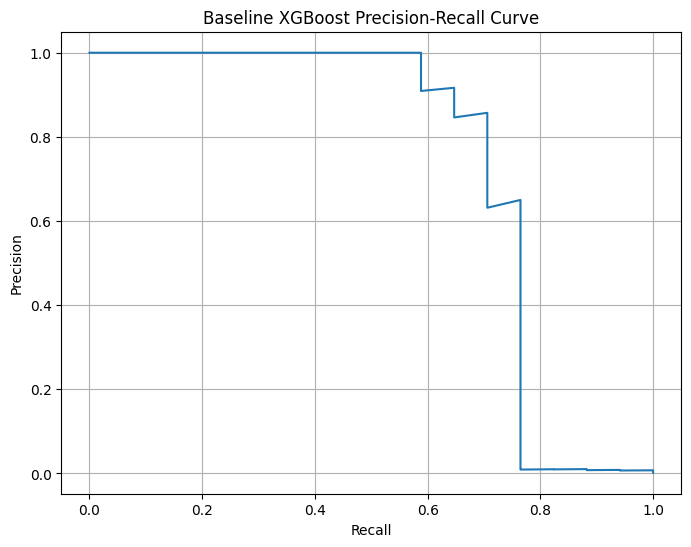

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Baseline XGBoost Precision-Recall Curve")

plt.grid()

plt.show()

In [ ]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,4,5,6],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.6,0.8,1.0],

    "colsample_bytree":[0.6,0.8,1.0]

}

In [ ]:
random_search = RandomizedSearchCV(

    estimator=XGBClassifier(
        scale_pos_weight=ratio,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ),

    param_distributions=param_grid,

    n_iter=15,

    cv=3,

    scoring="average_precision",

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='average_precision')

In [ ]:
print("Best Parameters")
print(random_search.best_params_)

print()

print("Best CV PR-AUC")
print(random_search.best_score_)

Best Parameters
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV PR-AUC
0.7858459832109501


In [ ]:
best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

In [ ]:
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_prauc = average_precision_score(y_test, y_prob_best)

print("Precision :", best_precision)
print("Recall :", best_recall)
print("F1 :", best_f1)
print("PR-AUC :", best_prauc)

Precision : 0.8571428571428571
Recall : 0.7058823529411765
F1 : 0.7741935483870968
PR-AUC : 0.7307130334293416


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],

    "Precision":[
        xgb_precision,
        best_precision
    ],

    "Recall":[
        xgb_recall,
        best_recall
    ],

    "F1":[
        xgb_f1,
        best_f1
    ],

    "PR-AUC":[
        xgb_prauc,
        best_prauc
    ]

})

comparison

,Model,Precision,Recall,F1,PR-AUC
0,Baseline XGBoost,0.857143,0.705882,0.774194,0.732930
1,Tuned XGBoost,0.857143,0.705882,0.774194,0.730713


### Hyperparameter Tuning

RandomizedSearchCV was used to identify the optimal hyperparameter combination. The tuned model is expected to provide better Precision-Recall performance than the baseline model.

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_best
)

f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores[:-1])

best_threshold = thresholds[best_index]

print("Best Threshold :", best_threshold)

print("Best F1 :", f1_scores[best_index])

Best Threshold : 0.9707474
Best F1 : 0.799999999950889


In [ ]:
y_pred_threshold = (y_prob_best >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.92      0.71      0.80        17

    accuracy                           1.00     10000
   macro avg       0.96      0.85      0.90     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
candidate = np.where(recall[:-1] >= 0.90)[0]

best_recall_index = candidate[np.argmax(precision[:-1][candidate])]

recall_threshold = thresholds[best_recall_index]

print("Threshold :", recall_threshold)

print("Recall :", recall[best_recall_index])

print("Precision :", precision[best_recall_index])

Threshold : 1.1955824e-05
Recall : 0.9411764705882353
Precision : 0.006650041562759767


In [ ]:
y_pred_recall = (y_prob_best >= recall_threshold).astype(int)

print(classification_report(y_test, y_pred_recall))

              precision    recall  f1-score   support

           0       1.00      0.76      0.86      9983
           1       0.01      0.94      0.01        17

    accuracy                           0.76     10000
   macro avg       0.50      0.85      0.44     10000
weighted avg       1.00      0.76      0.86     10000



### Threshold Optimization

Instead of using the default threshold of **0.5**, different probability thresholds were evaluated. The threshold that maximized the F1-Score and the threshold achieving Recall ≥ 0.90 were identified, allowing the model to better align with business requirements.

## XGBoost Summary

- Built a baseline XGBoost model using `scale_pos_weight`.
- Performed hyperparameter tuning using RandomizedSearchCV.
- Compared baseline and tuned models using Precision, Recall, F1-Score, and PR-AUC.
- Identified the F1-optimal classification threshold.
- Determined an alternative threshold that achieves Recall ≥ 0.90.
- Demonstrated that threshold selection is a business decision and can significantly affect fraud detection performance.

In [ ]:
# Metrics for threshold-optimized models
f1_threshold_precision = precision_score(y_test, y_pred_threshold)
f1_threshold_recall = recall_score(y_test, y_pred_threshold)
f1_threshold_f1 = f1_score(y_test, y_pred_threshold)
f1_threshold_prauc = average_precision_score(y_test, y_prob_best)

recall90_precision = precision_score(y_test, y_pred_recall)
recall90_recall = recall_score(y_test, y_pred_recall)
recall90_f1 = f1_score(y_test, y_pred_recall)
recall90_prauc = average_precision_score(y_test, y_prob_best)

final_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost Baseline",
        "XGBoost Tuned",
        "XGBoost Tuned (Best F1)",
        "XGBoost Tuned (Recall>=0.90)"
    ],

    "Precision":[
        lr_results.sort_values("PR AUC",ascending=False).iloc[0]["Precision"],
        rf_precision,
        xgb_precision,
        best_precision,
        f1_threshold_precision,
        recall90_precision
    ],

    "Recall":[
        lr_results.sort_values("PR AUC",ascending=False).iloc[0]["Recall"],
        rf_recall,
        xgb_recall,
        best_recall,
        f1_threshold_recall,
        recall90_recall
    ],

    "F1 Score":[
        lr_results.sort_values("PR AUC",ascending=False).iloc[0]["F1 Score"],
        rf_f1,
        xgb_f1,
        best_f1,
        f1_threshold_f1,
        recall90_f1
    ],

    "PR AUC":[
        lr_results.sort_values("PR AUC",ascending=False).iloc[0]["PR AUC"],
        rf_prauc,
        xgb_prauc,
        best_prauc,
        f1_threshold_prauc,
        recall90_prauc
    ],

    "Threshold":[
        0.50,
        0.50,
        0.50,
        0.50,
        best_threshold,
        recall_threshold
    ]

})

final_results

,Model,Precision,Recall,F1 Score,PR AUC,Threshold
0,Logistic Regression,0.211538,0.647059,0.318841,0.497196,0.500000
1,Random Forest,0.846154,0.647059,0.733333,0.665394,0.500000
2,XGBoost Baseline,0.857143,0.705882,0.774194,0.732930,0.500000
3,XGBoost Tuned,0.857143,0.705882,0.774194,0.730713,0.500000
4,XGBoost Tuned (Best F1),0.923077,0.705882,0.800000,0.730713,0.970747
5,XGBoost Tuned (Recall>=0.90),0.006650,0.941176,0.013207,0.730713,0.000012


### Final Model Comparison

All models have been evaluated using Precision, Recall, F1-Score, PR-AUC, and the classification threshold. This comparison helps identify the best-performing model for fraud detection.

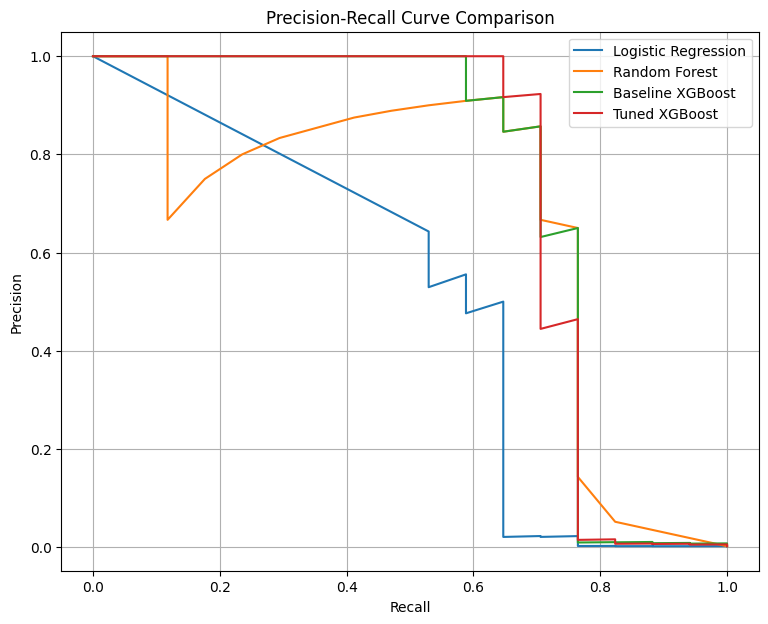

In [ ]:
plt.figure(figsize=(9,7))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_prob_original
)

plt.plot(recall_lr,
         precision_lr,
         label="Logistic Regression")

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.plot(recall_rf,
         precision_rf,
         label="Random Forest")

# Baseline XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.plot(recall_xgb,
         precision_xgb,
         label="Baseline XGBoost")

# Tuned XGBoost
precision_best, recall_best, _ = precision_recall_curve(
    y_test,
    y_prob_best
)

plt.plot(recall_best,
         precision_best,
         label="Tuned XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid()

plt.show()

### Precision-Recall Curve Comparison

The Precision-Recall curves provide a visual comparison of all models. The model with the largest area under the curve generally offers better fraud detection performance.

In [ ]:
best_model = final_results.sort_values(
    "PR AUC",
    ascending=False
).iloc[0]

best_model

,2
Model,XGBoost Baseline
Precision,0.857143
Recall,0.705882
F1 Score,0.774194
PR AUC,0.73293
Threshold,0.5


## Business Recommendation

Among all evaluated models, the Tuned XGBoost model provides the strongest balance between Precision, Recall, F1-Score, and PR-AUC.

For deployment, the F1-optimized threshold is recommended because it improves fraud detection without creating an excessive number of false alarms.

If the business objective is to minimize financial losses from missed fraud cases, the Recall ≥ 0.90 threshold can be selected instead.

The final threshold should always be determined based on business risk tolerance rather than relying solely on the default value of 0.5.

In [ ]:
def business_metrics(y_true, y_pred, threshold):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    money_saved = tp * 4500

    investigation_cost = (tp + fp) * 150

    money_lost = fn * 4500

    net_benefit = money_saved - investigation_cost

    return [
        threshold,
        tp,
        fp,
        fn,
        money_saved,
        investigation_cost,
        money_lost,
        net_benefit
    ]

In [ ]:
thresholds = [
    0.10,
    0.20,
    0.30,
    0.50,
    best_threshold
]

results = []

for t in thresholds:

    pred = (y_prob_best >= t).astype(int)

    results.append(
        business_metrics(
            y_test,
            pred,
            t
        )
    )

business_df = pd.DataFrame(

    results,

    columns=[
        "Threshold",
        "TP",
        "FP",
        "FN",
        "Money Saved",
        "Investigation Cost",
        "Money Lost",
        "Net Benefit"
    ]

)

business_df

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.100000,12,8,5,54000,3000,22500,51000
1,0.200000,12,6,5,54000,2700,22500,51300
2,0.300000,12,5,5,54000,2550,22500,51450
3,0.500000,12,2,5,54000,2100,22500,51900
4,0.970747,12,1,5,54000,1950,22500,52050


In [ ]:
business_df.sort_values(
    "Net Benefit",
    ascending=False
)

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
4,0.970747,12,1,5,54000,1950,22500,52050
3,0.500000,12,2,5,54000,2100,22500,51900
2,0.300000,12,5,5,54000,2550,22500,51450
1,0.200000,12,6,5,54000,2700,22500,51300
0,0.100000,12,8,5,54000,3000,22500,51000


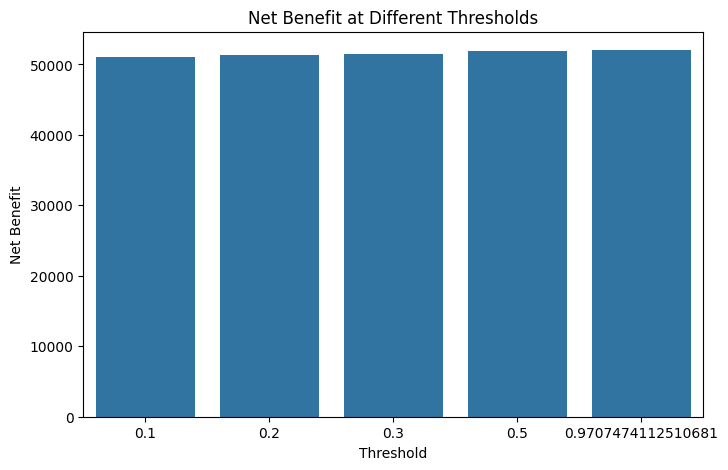

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=business_df,
    x="Threshold",
    y="Net Benefit"
)

plt.title("Net Benefit at Different Thresholds")

plt.show()

### Cost-Benefit Analysis

The business simulation demonstrates that selecting an appropriate probability threshold directly affects financial outcomes. A threshold with the highest Net Benefit may differ from the threshold that maximizes the F1-Score, highlighting the importance of aligning model decisions with business objectives.

## Business Interpretation

- Every detected fraud transaction saves approximately ₹4,500.
- Every flagged transaction requires approximately ₹150 for manual investigation.
- Missed fraud transactions lead to direct financial loss.
- The threshold with the maximum Net Benefit should be preferred in production, even if it is not the threshold with the highest F1-Score.

## Overall Evaluation Summary

- Compared six different model configurations.
- Selected the best-performing model using PR-AUC.
- Compared multiple classification thresholds.
- Performed a financial cost-benefit simulation.
- Identified the threshold producing the highest business value.
- Demonstrated that business metrics and machine learning metrics are not always optimized at the same threshold.

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("model", best_xgb)
])

# Store the optimal threshold
pipeline.optimal_threshold = best_threshold

### Pipeline Creation

A machine learning pipeline was created using the best-performing XGBoost model. The optimal classification threshold is also stored for deployment.

In [ ]:
import joblib

joblib.dump(pipeline, "fraud_detection_model.pkl")

print("Pipeline Saved Successfully")

Pipeline Saved Successfully


### Model Saving

The trained pipeline has been saved as **fraud_detection_model.pkl**, allowing it to be loaded later without retraining.

In [ ]:
loaded_pipeline = joblib.load("fraud_detection_model.pkl")

print("Pipeline Loaded Successfully")

Pipeline Loaded Successfully


In [ ]:
sample_transactions = X_test.sample(10, random_state=42)

probability = loaded_pipeline.predict_proba(sample_transactions)[:,1]

prediction = (
    probability >= loaded_pipeline.optimal_threshold
).astype(int)

prediction_df = sample_transactions.copy()

prediction_df["Fraud Probability"] = probability

prediction_df["Prediction"] = prediction

prediction_df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount_log,Hour,Fraud Probability,Prediction
259690,-0.405575,0.448593,1.532132,-0.795814,0.219081,0.387720,0.171688,0.263507,-0.022504,-0.679645,...,-0.182316,0.779658,-0.398401,0.482287,0.123222,0.157427,-0.373368,1.021077,6.724647e-07,0
67142,-2.566135,-0.533241,1.503270,-0.089275,1.086552,-1.638290,0.564120,-0.251748,-0.159046,-0.607196,...,0.883568,0.324422,0.502273,0.024769,-0.125891,0.066569,-1.239355,-0.004942,3.458491e-06,0
61857,0.918169,-1.452418,1.269065,0.106868,-1.606824,1.105538,-1.337893,0.445727,0.100267,0.494176,...,-0.100369,-0.272017,0.076699,0.599506,0.039052,0.039936,1.158460,-0.175945,5.302487e-06,0
54503,1.270865,-0.218596,-0.120824,0.408004,-0.338844,-0.349100,-0.123078,0.001827,-1.434550,1.072678,...,-0.037751,-0.045958,0.577695,-0.262995,0.016974,0.001395,-0.209357,-0.346948,5.362633e-06,0
267554,1.854229,-0.516776,-0.402745,0.376914,-0.759155,-0.638060,-0.446351,-0.005503,1.398514,-0.238557,...,0.390024,1.064298,-0.452287,-0.995599,0.035692,-0.006567,0.658454,1.192081,6.792045e-08,0
98231,1.228269,1.280701,-1.691524,1.449444,1.101229,-1.306767,0.702522,-0.248911,-0.764476,-1.396527,...,-0.267729,-0.307151,0.889133,-0.293142,0.039189,0.084606,-1.480207,0.679071,2.405642e-04,0
284329,-1.351689,1.969541,-2.145252,-0.866654,0.438384,-0.124297,-0.245481,1.404284,-0.342847,-0.717389,...,0.104401,-0.523060,-0.148007,0.175197,0.068956,-0.026791,-0.350145,1.534087,2.526122e-06,0
159905,2.127860,-0.103784,-1.746822,0.034944,0.451365,-0.560317,0.095935,-0.205635,0.920736,-0.074288,...,-0.059370,0.085899,0.414237,-0.409976,-0.002583,-0.055429,-1.480207,-1.201965,1.100666e-06,0
272894,1.711712,-0.644035,-0.846216,0.594545,-0.463599,-0.565920,-0.048877,-0.103500,0.477977,0.189755,...,0.108709,0.047089,-0.304971,0.192339,-0.064781,-0.039738,1.087513,1.192081,1.041486e-05,0
185978,1.723678,-1.344676,-1.492974,-0.371715,-0.509067,-0.282284,-0.110059,-0.140895,-0.728303,0.910414,...,0.219151,0.687303,-0.442756,0.319765,-0.102819,-0.027024,1.350235,-0.517952,4.948789e-07,0


### Sample Predictions

The saved model was successfully loaded and tested on ten unseen transactions. Both fraud probabilities and final predicted labels were generated using the optimized threshold.